# RTSP Stream Object Detection with PyTorch
Connects to an RTSP stream, runs inference with your `.pt` model, draws bounding boxes, and displays the annotated feed in real time.

## 1. Install Dependencies

In [2]:
# Fix NumPy ABI mismatch
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install",
    "numpy<2.0",
    "ultralytics>=8.3.100",
    "opencv-python-headless",
    "--upgrade",
    "--quiet"
])

print("Done — now restart the kernel before running anything else.")

Done — now restart the kernel before running anything else.


In [19]:
# Fix: ensure Ultralytics >= 8.3.100 is installed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "ultralytics>=8.3.100", "--quiet"])

# Then restart the kernel once after running this cell

0

In [1]:
import ultralytics
print(ultralytics.__version__)  # must be 8.3.100 or higher

from ultralytics import YOLO
model = YOLO("coverall.pt")
print(model.names)  # should print your class names (coverall, etc.)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Digichowk\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.63
{0: 'CoverAll', 1: 'NoCoverALL'}


## 2. Configuration — Edit These Values

In [2]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
RTSP_URL   = "rtsp://localhost:8554/webcam"  # your stream URL
MODEL_PATH = "./trained_models/coverall.pt"     # path to your .pt file
CONF_THRESH = 0.4           # minimum confidence to show a box (0.0 – 1.0)
IOU_THRESH  = 0.45          # NMS IoU threshold
DEVICE      = "cpu"         # "cpu", "cuda", or "mps" (Apple Silicon)
MAX_FRAMES  = 0             # 0 = run until manually stopped; N = stop after N frames
# ─────────────────────────────────────────────────────────────────────────────

# Box & label colours  (BGR)
BOX_COLOR   = (0, 255, 0)   # green boxes
TEXT_BG     = (0, 255, 0)
TEXT_COLOR  = (0, 0, 0)     # black text on label
BOX_THICK   = 2
FONT_SCALE  = 0.55
FONT_THICK  = 1

## 3. Load Model

In [3]:
from ultralytics import YOLO
import torch

model = YOLO(MODEL_PATH)
model.to(DEVICE)

print(f"Model loaded  →  {MODEL_PATH}")
print(f"Classes       →  {model.names}")
print(f"Device        →  {DEVICE}")

Model loaded  →  ./trained_models/coverall.pt
Classes       →  {0: 'CoverAll', 1: 'NoCoverALL'}
Device        →  cpu


## 4. Helper — Draw Detections on a Frame

In [4]:
import cv2

def draw_detections(frame, results):
    """Draw bounding boxes and labels onto `frame` in-place."""
    for box in results[0].boxes:
        conf  = float(box.conf[0])
        cls   = int(box.cls[0])
        label = f"{model.names[cls]}  {conf:.2f}"

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Bounding box
        cv2.rectangle(frame, (x1, y1), (x2, y2), BOX_COLOR, BOX_THICK)

        # Label background pill
        (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX,
                                              FONT_SCALE, FONT_THICK)
        label_y = max(y1, th + 6)
        cv2.rectangle(frame,
                      (x1, label_y - th - 4),
                      (x1 + tw + 4, label_y + baseline),
                      TEXT_BG, cv2.FILLED)

        # Label text
        cv2.putText(frame, label, (x1 + 2, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, TEXT_COLOR, FONT_THICK)

    return frame

In [6]:
import datetime

ALERT_CLASSES = ["NoCoverALL"]   # trigger alert when these are detected
ALERT_COOLDOWN = 10              # seconds between repeated alerts for the same class

last_alert = {}

def check_alerts(results):
    now = datetime.datetime.now()
    for box in results[0].boxes:
        cls_name = model.names[int(box.cls[0])]
        conf     = float(box.conf[0])
        if cls_name in ALERT_CLASSES:
            last = last_alert.get(cls_name)
            if last is None or (now - last).seconds >= ALERT_COOLDOWN:
                last_alert[cls_name] = now
                print(f"⚠️  ALERT [{now.strftime('%H:%M:%S')}]  "
                      f"{cls_name} detected  (conf={conf:.2f})")

## 5. Run Inference on RTSP Stream

> **Notebook display mode** — frames are shown inline via `IPython.display`.
> Press the **■ Stop** button (or interrupt the kernel) to end the loop.

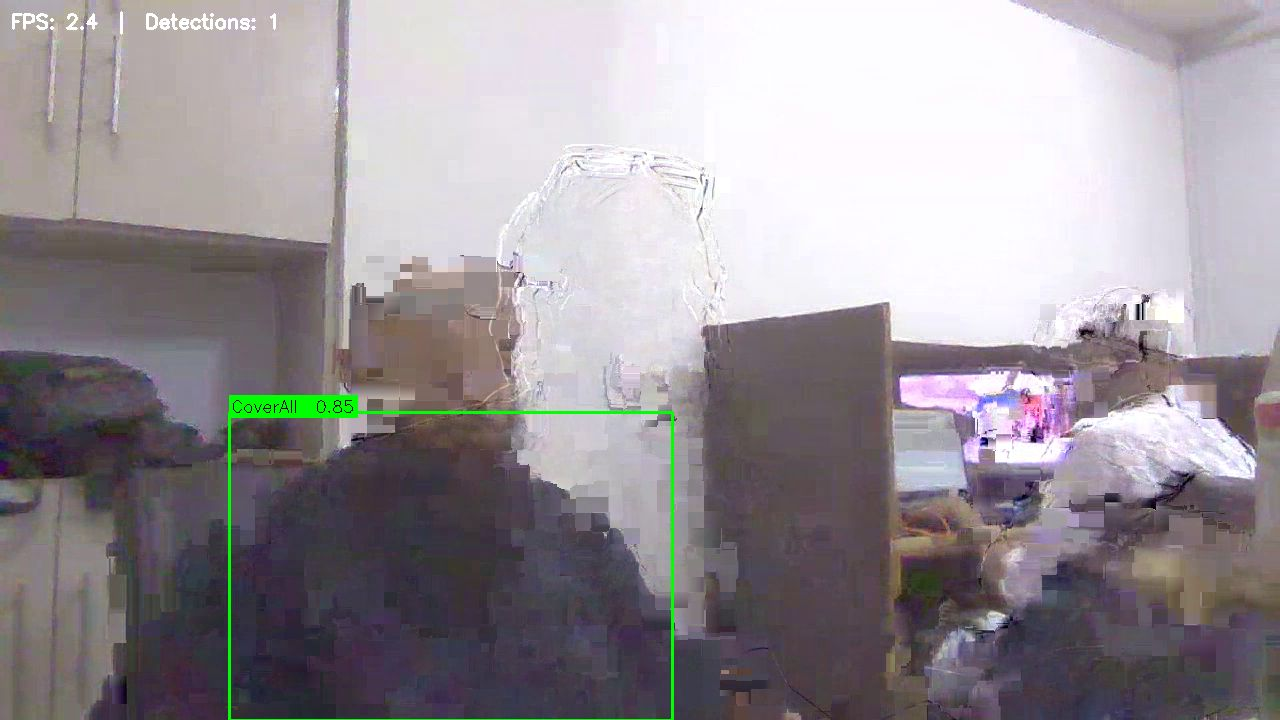

Interrupted by user.
Done. Processed 279 frames in 117.7s  (avg 2.4 FPS)


In [ ]:
import cv2
import time
import IPython.display as ipd
from IPython.display import clear_output
from PIL import Image
import io

cap = cv2.VideoCapture(RTSP_URL)

if not cap.isOpened():
    raise RuntimeError(f"Cannot open stream: {RTSP_URL}\n"
                       "Check the URL, credentials, and that the camera is reachable.")

fps_src = cap.get(cv2.CAP_PROP_FPS) or 25
print(f"Stream opened  —  source FPS: {fps_src:.1f}")

frame_count  = 0
t_start      = time.time()

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Stream ended or frame read failed.")
            break

        # ── Inference ────────────────────────────────────────────────────────
        results = model.predict(
            source   = frame,
            conf     = CONF_THRESH,
            iou      = IOU_THRESH,
            device   = DEVICE,
            verbose  = False,
        )
        check_alerts(results)
        # ── Annotate ─────────────────────────────────────────────────────────
        annotated = draw_detections(frame.copy(), results)
        

        # ── FPS overlay ──────────────────────────────────────────────────────
        frame_count += 1
        elapsed = time.time() - t_start
        fps_live = frame_count / elapsed if elapsed > 0 else 0
        n_det = len(results[0].boxes)

        cv2.putText(annotated,
                    f"FPS: {fps_live:.1f}  |  Detections: {n_det}",
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

        # ── Display in notebook (BGR → RGB → JPEG → IPython) ─────────────────
        rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(rgb)
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=80)
        clear_output(wait=True)
        ipd.display(ipd.Image(buf.getvalue()))
        
        if MAX_FRAMES and frame_count >= MAX_FRAMES:
            print(f"Reached MAX_FRAMES = {MAX_FRAMES}. Stopping.")
            break

except KeyboardInterrupt:
    print("Interrupted by user.")
finally:
    cap.release()
    print(f"Done. Processed {frame_count} frames in {elapsed:.1f}s  "
          f"(avg {fps_live:.1f} FPS)")

## 6. (Optional) Save Annotated Video to Disk

In [10]:
OUTPUT_VIDEO = "output_annotated.mp4"
SAVE_FRAMES  = 300   # number of frames to record

cap = cv2.VideoCapture(RTSP_URL)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open stream: {RTSP_URL}")

w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps, (w, h)
)

print(f"Recording {SAVE_FRAMES} frames → {OUTPUT_VIDEO}  ({w}×{h} @ {fps:.0f} FPS)")

for i in range(SAVE_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break
    results   = model.predict(frame, conf=CONF_THRESH, iou=IOU_THRESH,
                               device=DEVICE, verbose=False)
    annotated = draw_detections(frame.copy(), results)
    writer.write(annotated)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{SAVE_FRAMES} frames written…")

cap.release()
writer.release()
print(f"Video saved: {OUTPUT_VIDEO}")

Recording 300 frames → output_annotated.mp4  (1280×720 @ 30 FPS)
  50/300 frames written…
  100/300 frames written…
  150/300 frames written…
  200/300 frames written…
  250/300 frames written…
  300/300 frames written…
Video saved: output_annotated.mp4


## 7. (Optional) Single-Frame Test — No Stream Required
Useful to verify the model is working before connecting to a live stream.

In [8]:
TEST_IMAGE = "test.jpg"   # replace with any image path

import cv2, IPython.display as ipd, io
from PIL import Image

frame   = cv2.imread(TEST_IMAGE)
results = model.predict(frame, conf=CONF_THRESH, iou=IOU_THRESH,
                         device=DEVICE, verbose=False)
annotated = draw_detections(frame.copy(), results)

rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
buf = io.BytesIO()
Image.fromarray(rgb).save(buf, format="JPEG", quality=90)
ipd.display(ipd.Image(buf.getvalue()))

print(f"{len(results[0].boxes)} object(s) detected")
for box in results[0].boxes:
    cls  = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"  {model.names[cls]:20s}  conf={conf:.2f}  box={list(map(int, box.xyxy[0]))}")

WARNING 'source' is missing. Using 'source=C:\Users\Digichowk\AppData\Local\Programs\Python\Python310\Lib\site-packages\ultralytics\assets'.


AttributeError: 'NoneType' object has no attribute 'copy'

---
### Troubleshooting

| Problem | Fix |
|---|---|
| `Cannot open stream` | Check the RTSP URL, credentials, firewall, and VPN |
| Very low FPS | Lower `CONF_THRESH`, reduce input resolution, or use GPU (`DEVICE = "cuda"`) |
| Model loads but no detections | Lower `CONF_THRESH`; verify the model's class list |
| `ModuleNotFoundError: ultralytics` | Re-run cell 1 and restart the kernel |
| Frames display slowly | Increase `quality=80` → `quality=50` in the JPEG encode step |